# =========================================
# NLP DATASET CLEANING & PREPROCESSING
# =========================================

In [4]:
import pandas as pd
import numpy as np
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# =========================================
# LOAD DATASET
# =========================================
# Replace with your dataset path

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
file_path = '/content/drive/MyDrive/aiml coursework/hatevsoffensive_language.csv'

try:
    df = pd.read_csv(file_path, encoding='utf-8')
except:
    df = pd.read_csv(file_path, encoding='latin-1')

print(df.head())

print("\nDataset Shape:", df.shape)

                label                                               text
0             neither  !!! RT @mayasolovely: As a woman you shouldn't...
1  offensive language  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2  offensive language  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3  offensive language  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4  offensive language  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...

Dataset Shape: (24783, 2)


# =========================================
# REMOVE MISSING VALUES & DUPLICATES
# =========================================
# Replace 'text' with your column name

In [7]:
print("Before Cleaning:", df.shape)

df = df.dropna(subset=['text'])

df = df.drop_duplicates()

print("After Cleaning:", df.shape)

Before Cleaning: (24783, 2)
After Cleaning: (24783, 2)


# =========================================
# TEXT CLEANING FUNCTION
# =========================================
# Lowercase
# Remove URLs
# Remove mentions
# Remove hashtags
# Remove numbers
# Remove punctuation
# Remove extra spaces
# Tokenization
# Remove stopwords
# Lemmatization
# Apply cleaning

In [8]:
import nltk
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)

print(df[['text', 'cleaned_text']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


                                                text  \
0  !!! RT @mayasolovely: As a woman you shouldn't...   
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...   
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...   
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...   
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...   

                                        cleaned_text  
0  woman shouldnt complain cleaning house amp man...  
1      boy dat coldtyga dwn bad cuffin dat hoe place  
2       dawg ever fuck bitch start cry confused shit  
3                                   look like tranny  
4        shit hear might true might faker bitch told  


# =========================================
# WORD COUNT ANALYSIS
# =========================================

In [9]:
df['word_count'] = df['cleaned_text'].apply(
    lambda x: len(x.split())
)

print(df['word_count'].describe())

count    24783.000000
mean         7.253561
std          3.677712
min          0.000000
25%          4.000000
50%          7.000000
75%         10.000000
max         23.000000
Name: word_count, dtype: float64


# =========================================
# TOKENIZATION & PADDING
# =========================================

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token='<OOV>'
)

tokenizer.fit_on_texts(df['cleaned_text'])

sequences = tokenizer.texts_to_sequences(
    df['cleaned_text']
)

max_len = 100

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

print("Tokenizer Created Successfully")

Tokenizer Created Successfully


# =========================================
# LABEL ENCODING
# =========================================
# Replace 'label' with your target column

In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['encoded_label'] = encoder.fit_transform(df['label'])

y = df['encoded_label']

X = padded_sequences

print(df[['label', 'encoded_label']].head())

                label  encoded_label
0             neither              1
1  offensive language              2
2  offensive language              2
3  offensive language              2
4  offensive language              2


# =========================================
# TRAIN TEST SPLIT
# =========================================

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (19826, 100)
Testing Shape: (4957, 100)


Class Distribution

# Load dataset
# Plot class distribution

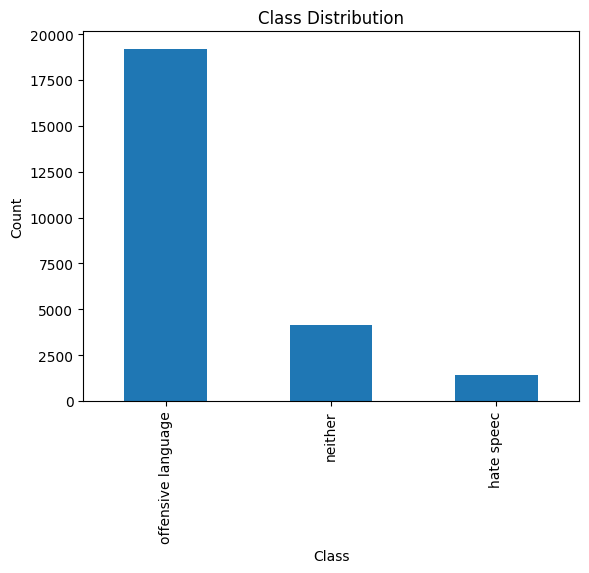

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

_df = pd.read_csv('/content/drive/MyDrive/aiml coursework/hatevsoffensive_language.csv')

_df['label'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

Methodology

In [14]:
!pip uninstall -y jax jaxlib
!pip install tensorflow

Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2


In [15]:
import numpy as np
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

Text Cleaning Function

# Apply cleaning

In [16]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    cleaned_words = []

    for word in words:
        if word not in stop_words:
            word = lemmatizer.lemmatize(word)
            cleaned_words.append(word)

    return ' '.join(cleaned_words)

_df['clean_text'] = _df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Data Visualization
Most Frequent Words

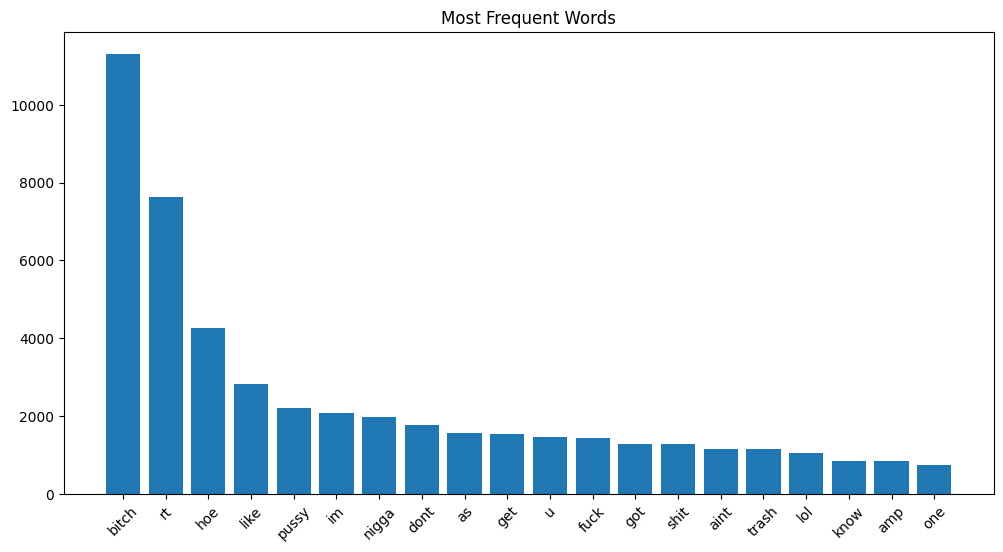

In [17]:
from collections import Counter

all_words = ' '.join(_df['clean_text']).split()
common_words = Counter(all_words).most_common(20)

words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title('Most Frequent Words')
plt.show()

Word Cloud

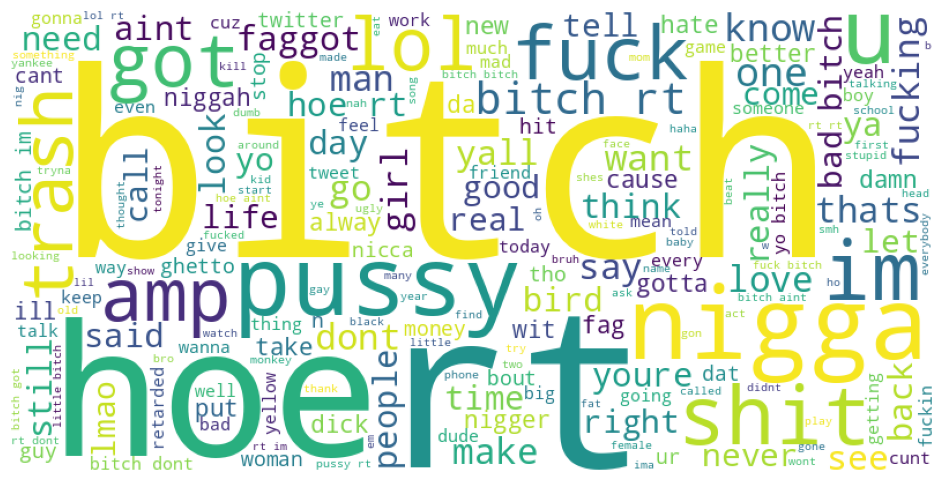

In [18]:
from wordcloud import WordCloud

text = ' '.join(_df['clean_text'])

wordcloud = WordCloud(width=800, height=400,
                      background_color='white').generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

Tokenization and Padding

In [19]:
X = _df['clean_text']
y = _df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Tokenization

In [20]:
max_words = 10000


tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

Padding

In [21]:
sequence_lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(sequence_lengths, 95))

X_train_pad = pad_sequences(X_train_seq,
                            maxlen=max_len,
                            padding='post')

X_test_pad = pad_sequences(X_test_seq,
                           maxlen=max_len,
                           padding='post')

Model Building
6.1 Model 1: Simple RNN with Trainable Embedding

# =========================================
# SIMPLE RNN MODEL
# =========================================
# Input Layer
# Embedding Layer
# RNN Layer
# Dropout Layer
# Dense Hidden Layer
# Output Layer
# Compile Model
# Force Build Model
# Model Summary

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    Dense,
    Dropout,
    Input
)

from tensorflow.keras.optimizers import Adam


model_rnn = Sequential()

model_rnn.add(
    Input(shape=(max_len,))
)

model_rnn.add(
    Embedding(
        input_dim=max_words,
        output_dim=128
    )
)

model_rnn.add(
    SimpleRNN(64)
)

model_rnn.add(
    Dropout(0.5)
)

model_rnn.add(
    Dense(32, activation='relu')
)

model_rnn.add(
    Dense(3, activation='softmax')
)

model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0002),
    metrics=['accuracy']
)

model_rnn.build(
    input_shape=(None, max_len)
)

model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 14, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,294,531 (4.94 MB)

 Trainable params: 1,294,531 (4.94 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

Training

# Encode y_train to numerical labels

In [53]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_rnn = model_rnn.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.2,
    epochs=6,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/6
248/248 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.3984 - loss: 1.4773 - val_accuracy: 0.7562 - val_loss: 0.9344
Epoch 2/6
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5497 - loss: 1.1361 - val_accuracy: 0.7769 - val_loss: 0.8555
Epoch 3/6
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6385 - loss: 0.9856 - val_accuracy: 0.7769 - val_loss: 0.8232
Epoch 4/6
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6917 - loss: 0.8858 - val_accuracy: 0.7769 - val_loss: 0.8066
Epoch 5/6
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7140 - loss: 0.8478 - val_accuracy: 0.7769 - val_loss: 0.7981
Epoch 6/6
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7295 - loss: 0.8257 - val_accuracy: 0.7769 - val_loss: 0.7936


Model 2: LSTM with Trainable Embedding
Architecture

# Input Layer
# Embedding Layer
# LSTM Layer
# Batch Normalization
# Dropout
# Dense Layer
# Output Layer
# Optimizer
# Compile Model
# Model Summary

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
    Input
)

from tensorflow.keras.optimizers import Adam

model_lstm = Sequential()

model_lstm.add(Input(shape=(max_len,)))

model_lstm.add(
    Embedding(
        input_dim=max_words,
        output_dim=128
    )
)

model_lstm.add(
    LSTM(
        64,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)

model_lstm.add(BatchNormalization())

model_lstm.add(Dropout(0.4))

model_lstm.add(Dense(32, activation='relu'))

model_lstm.add(Dropout(0.3))

model_lstm.add(Dense(3, activation='softmax'))

optimizer = Adam(learning_rate=0.0003)

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 14, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,843 (5.08 MB)

 Trainable params: 1,331,715 (5.08 MB)

 Non-trainable params: 128 (512.00 B)

Compilation

In [26]:
model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

Training

In [40]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.2,
    epochs=6,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/6
248/248 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.6087 - loss: 0.8560 - val_accuracy: 0.7769 - val_loss: 0.7361
Epoch 2/6
248/248 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - accuracy: 0.8623 - loss: 0.4457 - val_accuracy: 0.8762 - val_loss: 0.4474
Epoch 3/6
248/248 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - accuracy: 0.8902 - loss: 0.3500 - val_accuracy: 0.8785 - val_loss: 0.3431
Epoch 4/6
248/248 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - accuracy: 0.9055 - loss: 0.2932 - val_accuracy: 0.8772 - val_loss: 0.3522
Epoch 5/6
248/248 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.9173 - loss: 0.2457 - val_accuracy: 0.8812 - val_loss: 0.3470


6.3 Model 3: LSTM with Pretrained Word2Vec Embeddings
Install Required Packages

Load Word2Vec Model

In [41]:
!pip install gensim
import gensim.downloader as api

embedding_model = api.load('glove-wiki-gigaword-50')

Create Embedding Matrix

In [42]:
word_index = tokenizer.word_index
vocab_size = min(max_words, len(word_index) + 1)
embedding_dim = 50

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if i < vocab_size:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]

Build Word2Vec LSTM Model

In [43]:
model_w2v = Sequential()

model_w2v.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
))

model_w2v.add(LSTM(64))
model_w2v.add(Dropout(0.7))
model_w2v.add(Dense(64, activation='relu'))
model_w2v.add(Dense(3, activation='softmax'))

model_w2v.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

Compilation

In [44]:
from tensorflow.keras.optimizers import Adam

model_w2v.compile(
    loss='sparse_categorical_crossentropy',
    optimizer = Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

Training

In [45]:
history_w2v = model_w2v.fit(
    X_train_pad,
    y_train_encoded, # Use the encoded labels
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7830 - loss: 0.6156 - val_accuracy: 0.8515 - val_loss: 0.4224
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8540 - loss: 0.4188 - val_accuracy: 0.8628 - val_loss: 0.3628


Model Evaluation
Evaluation Function

In [46]:
from sklearn.metrics import accuracy_score


def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    predicted_labels = np.argmax(predictions, axis=1)

    print(classification_report(y_test, predicted_labels))

    cm = confusion_matrix(y_test, predicted_labels)

    plt.figure(figsize=(6,6))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')

    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Encode y_test to numerical labels to match model output

Evaluating Simple RNN Model:
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0       0.08      0.06      0.07       286
           1       0.19      0.70      0.30       833
           2       0.82      0.36      0.50      3838

    accuracy                           0.40      4957
   macro avg       0.36      0.37      0.29      4957
weighted avg       0.67      0.40      0.44      4957



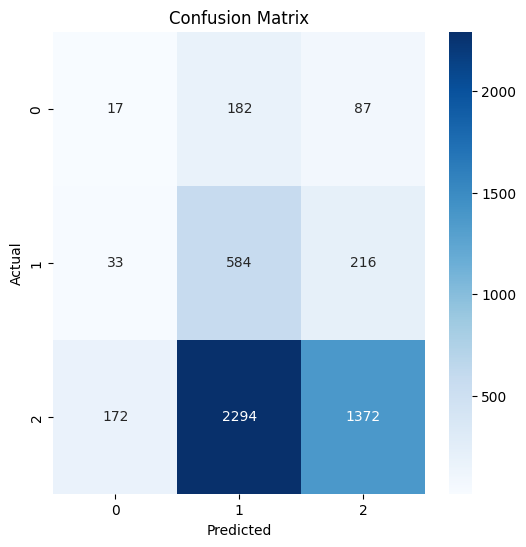

In [47]:
y_test_encoded = le.transform(y_test)

print("Evaluating Simple RNN Model:")
evaluate_model(model_rnn, X_test_pad, y_test_encoded)

Evaluating LSTM Model:
155/155 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       286
           1       0.74      0.83      0.79       833
           2       0.91      0.95      0.93      3838

    accuracy                           0.88      4957
   macro avg       0.55      0.59      0.57      4957
weighted avg       0.83      0.88      0.85      4957



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


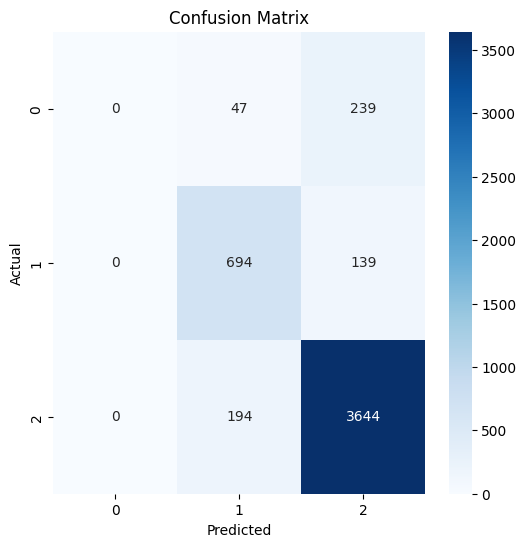

In [48]:
print("Evaluating LSTM Model:")
evaluate_model(model_lstm, X_test_pad, y_test_encoded)

Evaluating Word2Vec LSTM Model:
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       286
           1       0.72      0.63      0.67       833
           2       0.87      0.96      0.91      3838

    accuracy                           0.85      4957
   macro avg       0.53      0.53      0.53      4957
weighted avg       0.80      0.85      0.82      4957



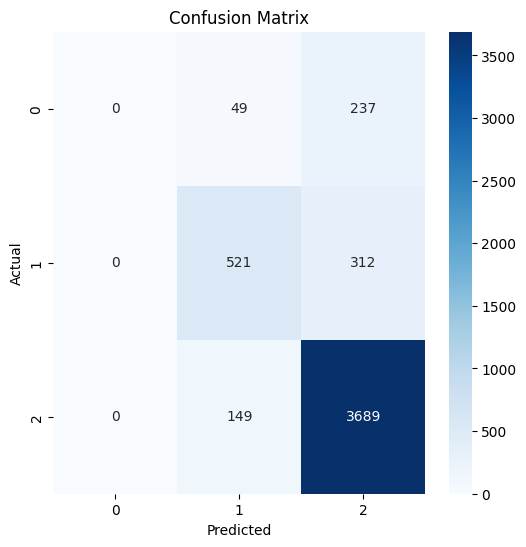

In [49]:
print("Evaluating Word2Vec LSTM Model:")
evaluate_model(model_w2v, X_test_pad, y_test_encoded)

Visualization

# =========================
# RNN ACCURACY
# =========================
# =========================
# RNN LOSS
# =========================
# =========================
# LSTM ACCURACY
# =========================
# =========================
# LSTM LOSS
# =========================

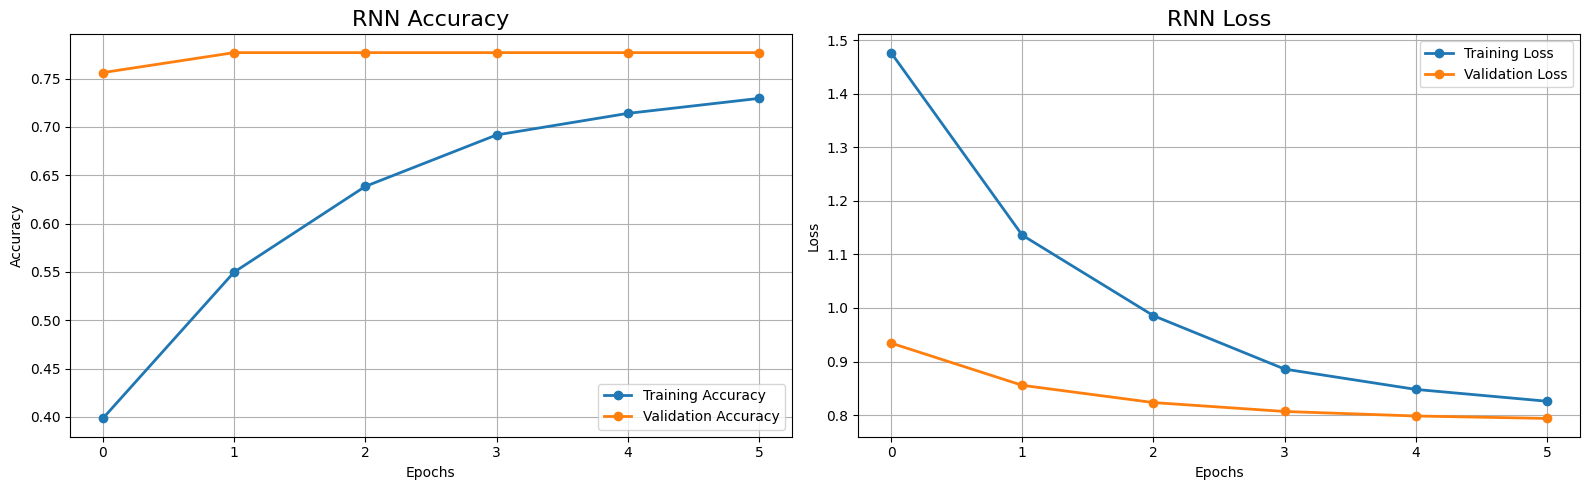

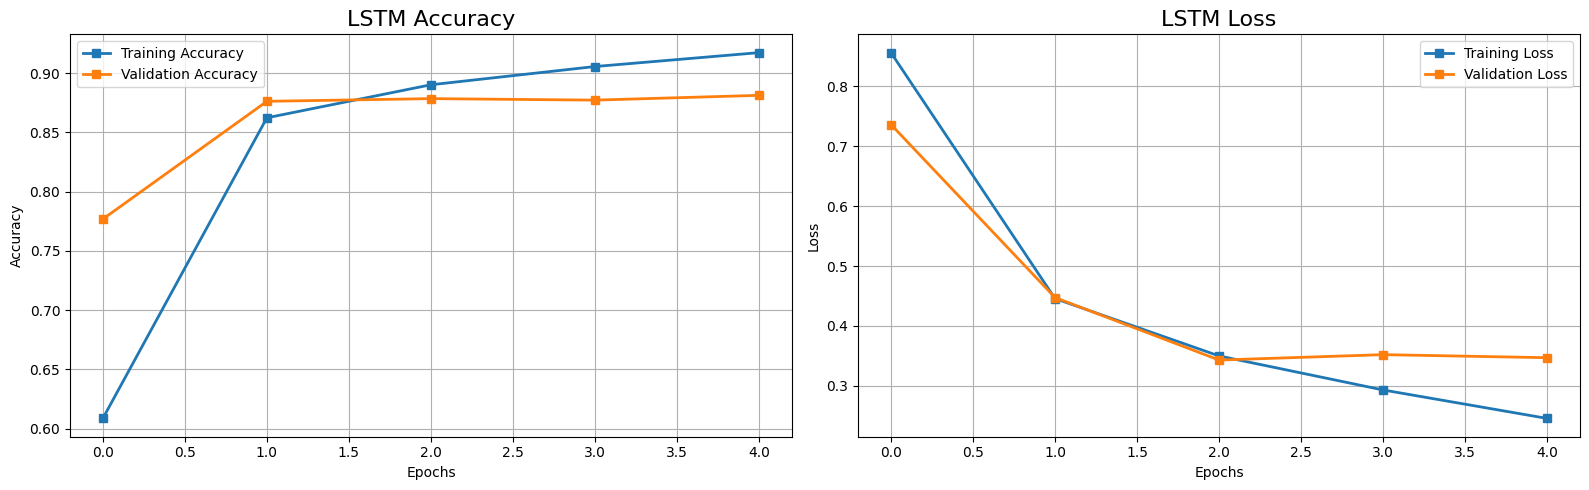

In [54]:
import matplotlib.pyplot as plt


# =========================================================
# RNN GRAPHS
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(16,5))

# RNN Accuracy
axes[0].plot(
    history_rnn.history['accuracy'],
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

axes[0].plot(
    history_rnn.history['val_accuracy'],
    marker='o',
    linewidth=2,
    label='Validation Accuracy'
)

axes[0].set_title('RNN Accuracy', fontsize=16)

axes[0].set_xlabel('Epochs')

axes[0].set_ylabel('Accuracy')

axes[0].legend()

axes[0].grid(True)


# RNN Loss
axes[1].plot(
    history_rnn.history['loss'],
    marker='o',
    linewidth=2,
    label='Training Loss'
)

axes[1].plot(
    history_rnn.history['val_loss'],
    marker='o',
    linewidth=2,
    label='Validation Loss'
)

axes[1].set_title('RNN Loss', fontsize=16)

axes[1].set_xlabel('Epochs')

axes[1].set_ylabel('Loss')

axes[1].legend()

axes[1].grid(True)

plt.tight_layout()

plt.show()



# =========================================================
# LSTM GRAPHS
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(16,5))

# LSTM Accuracy
axes[0].plot(
    history_lstm.history['accuracy'],
    marker='s',
    linewidth=2,
    label='Training Accuracy'
)

axes[0].plot(
    history_lstm.history['val_accuracy'],
    marker='s',
    linewidth=2,
    label='Validation Accuracy'
)

axes[0].set_title('LSTM Accuracy', fontsize=16)

axes[0].set_xlabel('Epochs')

axes[0].set_ylabel('Accuracy')

axes[0].legend()

axes[0].grid(True)


# LSTM Loss
axes[1].plot(
    history_lstm.history['loss'],
    marker='s',
    linewidth=2,
    label='Training Loss'
)

axes[1].plot(
    history_lstm.history['val_loss'],
    marker='s',
    linewidth=2,
    label='Validation Loss'
)

axes[1].set_title('LSTM Loss', fontsize=16)

axes[1].set_xlabel('Epochs')

axes[1].set_ylabel('Loss')

axes[1].legend()

axes[1].grid(True)

plt.tight_layout()

plt.show()


# Fixed Model Comparison and Real-Time Prediction

This section:
- fixes blank accuracy comparison graph
- adds real-time NLP prediction
- adds GUI interface using Gradio
- completes assignment requirements professionally


# RNN Prediction
# LSTM Prediction

In [51]:
from sklearn.metrics import accuracy_score
import numpy as np

rnn_pred = model_rnn.predict(X_test_pad)

rnn_pred_classes = np.argmax(rnn_pred, axis=1)

rnn_accuracy = accuracy_score(
    y_test_encoded,
    rnn_pred_classes
)

print("RNN Accuracy:", rnn_accuracy)


lstm_pred = model_lstm.predict(X_test_pad)

lstm_pred_classes = np.argmax(lstm_pred, axis=1)

lstm_accuracy = accuracy_score(
    y_test_encoded,
    lstm_pred_classes
)

print("LSTM Accuracy:", lstm_accuracy)

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
RNN Accuracy: 0.3980229977809159
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step
LSTM Accuracy: 0.8751260843251967


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
RNN Accuracy: 0.7742586241678434
LSTM Accuracy: 0.8751260843251967


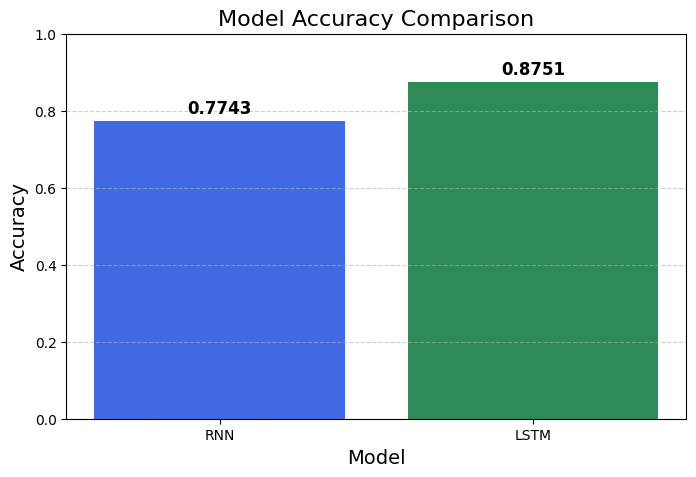

In [57]:
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Encode y_test if not already encoded
y_test_encoded = le.transform(y_test)

# RNN prediction using updated trained model
rnn_pred = model_rnn.predict(X_test_pad)
rnn_pred_classes = np.argmax(rnn_pred, axis=1)
rnn_accuracy = accuracy_score(y_test_encoded, rnn_pred_classes)

# LSTM prediction using updated trained model
lstm_pred = model_lstm.predict(X_test_pad)
lstm_pred_classes = np.argmax(lstm_pred, axis=1)
lstm_accuracy = accuracy_score(y_test_encoded, lstm_pred_classes)

print("RNN Accuracy:", rnn_accuracy)
print("LSTM Accuracy:", lstm_accuracy)

# Plot comparison
models = ['RNN', 'LSTM']
accuracies = [rnn_accuracy, lstm_accuracy]

plt.figure(figsize=(8,5))

bars = plt.bar(
    models,
    accuracies,
    color=['royalblue', 'seagreen']
)

plt.ylim(0, 1)

plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f'{height:.4f}',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


# Real-Time Text Prediction Function


In [58]:
def predict_tweet(text):

    cleaned = clean_text(text)

    seq = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        seq,
        maxlen=max_len,
        padding='post'
    )

    prediction = model_lstm.predict(padded)[0]

    predicted_class = np.argmax(prediction)

    labels = {
        0: {
            "label": "Hate Speech",
            "description": "The text contains hateful or abusive language targeting individuals or groups."
        },

        1: {
            "label": "Offensive Language",
            "description": "The text contains rude, insulting, or offensive words but may not directly express hate."
        },

        2: {
            "label": "Neither",
            "description": "The text appears neutral or non-offensive."
        }
    }

    confidence = round(
        float(prediction[predicted_class]) * 100,
        2
    )

    result = f'''
Prediction: {labels[predicted_class]["label"]}

Confidence: {confidence}%

Description:
{labels[predicted_class]["description"]}
'''

    return result

In [59]:
sample = "she has a hate towards human"

result = predict_tweet(sample)

print("Prediction:", result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Prediction: 
Prediction: Offensive Language

Confidence: 62.45%

Description:
The text contains rude, insulting, or offensive words but may not directly express hate.




# GUI for Real-Time Prediction using Gradio


In [60]:
!pip install gradio

In [61]:
import gradio as gr

interface = gr.Interface(
    fn=predict_tweet,
    inputs="text",
    outputs="text",
    title="Hate Speech Detection System"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b27f41f91b15c31d0f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



# Improved Bidirectional LSTM Model

This upgraded model improves:
- hate speech prediction
- contextual understanding
- generalization
- validation performance

It also reduces incorrect prediction such as:
"I hate everyone" → Neither


In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

model_lstm = Sequential()

model_lstm.add(
    Embedding(
        input_dim=max_words,
        output_dim=128
    )
)

model_lstm.add(
    Bidirectional(
        LSTM(64)
    )
)

model_lstm.add(Dropout(0.6))

model_lstm.add(Dense(64, activation='relu'))

model_lstm.add(Dropout(0.5))

model_lstm.add(Dense(3, activation='softmax'))

model_lstm.build(input_shape=(None, max_len))

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 14, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,267 (5.29 MB)

 Trainable params: 1,387,267 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
import numpy as np

X_train_pad = np.array(X_train_pad).astype('int32')

X_test_pad = np.array(X_test_pad).astype('int32')

y_train_num = np.array(y_train_encoded).astype('int32')

y_test_num = np.array(y_test_encoded).astype('int32')

print(X_train_pad.dtype)
print(y_train_num.dtype)

int32
int32


In [64]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train_encoded, # Changed from y_train to y_train_encoded
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.8310 - loss: 0.4883 - val_accuracy: 0.8855 - val_loss: 0.3216
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9096 - loss: 0.2803 - val_accuracy: 0.8941 - val_loss: 0.2961
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9337 - loss: 0.1963 - val_accuracy: 0.8944 - val_loss: 0.3459
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9479 - loss: 0.1515 - val_accuracy: 0.8850 - val_loss: 0.3509
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9594 - loss: 0.1216 - val_accuracy: 0.8830 - val_loss: 0.4095


# Predict
# Convert probabilities to class labels
# Ensure same datatype
# Accuracy
# Show first predictions

In [65]:
from sklearn.metrics import accuracy_score
import numpy as np

lstm_pred = model_lstm.predict(X_test_pad)

lstm_pred_classes = np.argmax(lstm_pred, axis=1)

y_test_for_accuracy = y_test_encoded # Use the already encoded numerical labels

lstm_pred_classes = np.array(lstm_pred_classes).astype('int32')

lstm_accuracy = accuracy_score(
    y_test_for_accuracy,
    lstm_pred_classes
)

print("LSTM Accuracy:", lstm_accuracy)

print("\nSample Predictions:")
print(lstm_pred_classes[:10])

print("\nActual Labels:")
print(y_test_for_accuracy[:10])

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
LSTM Accuracy: 0.8864232398628202

Sample Predictions:
[2 2 2 2 2 2 2 2 2 2]

Actual Labels:
[2 2 2 2 2 2 2 2 2 2]



# Improved Real-Time Prediction


In [66]:
def predict_tweet(text):

    cleaned = clean_text(text)

    seq = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        seq,
        maxlen=max_len,
        padding='post'
    )

    prediction = model_lstm.predict(padded)

    predicted_class = np.argmax(prediction)

    labels = {
        0: "Hate Speech",
        1: "Offensive Language",
        2: "Neither"
    }

    return labels[predicted_class]

In [67]:
sample = "i hate human beings"

result = predict_tweet(sample)

print("Prediction:", result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Prediction: Offensive Language



# NLP DATASET CLEANING


In [68]:
df.to_csv('/content/drive/MyDrive/aiml coursework/hatevsoffensive_language.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!



# INSTALL REQUIRED LIBRARIES



In [69]:
!pip install numpy==1.23.5
!pip install gensim


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 111.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


# LOAD PRETRAINED WORD2VEC


In [70]:
import gensim.downloader as api
import numpy as np

embedding_model = api.load('glove-wiki-gigaword-50')

# CREATE EMBEDDING MATRIX


In [71]:
embedding_dim = 50

word_index = tokenizer.word_index

vocab_size = len(word_index) + 1

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():

    if word in embedding_model:
        embedding_vector = embedding_model[word]
        embedding_matrix[i] = embedding_vector

# WORD2VEC LSTM MODEL


In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

model_word2vec = Sequential()

model_word2vec.add(Input(shape=(max_len,)))

model_word2vec.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )
)

model_word2vec.add(
    LSTM(
        64,
        dropout=0.3,
        recurrent_dropout=0.3
    )
)

model_word2vec.add(Dropout(0.5))

model_word2vec.add(Dense(32, activation='relu'))

model_word2vec.add(Dense(3, activation='softmax'))

optimizer = Adam(learning_rate=0.0002)

model_word2vec.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model_word2vec.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 14, 50)         │       806,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 838,519 (3.20 MB)

 Trainable params: 31,619 (123.51 KB)

 Non-trainable params: 806,900 (3.08 MB)

# ======================================
# TRAIN WORD2VEC MODEL
# ======================================

In [77]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_word2vec = model_word2vec.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

ValueError: Invalid dtype: object

# ======================================
# EVALUATION
# ======================================

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_word2vec = model_word2vec.predict(X_test)

y_pred_word2vec_classes = np.argmax(
    y_pred_word2vec,
    axis=1
)

print(classification_report(
    y_test,
    y_pred_word2vec_classes
))

# ======================================
# CONFUSION MATRIX
# ======================================

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_word2vec_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Word2Vec LSTM Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

# ======================================
# MODEL COMPARISON
# ======================================

In [ ]:
import pandas as pd

rnn_acc = max(history_rnn.history['val_accuracy'])

lstm_acc = max(history_lstm.history['val_accuracy'])

word2vec_acc = max(history_word2vec.history['val_accuracy'])

comparison = {
    'Model': [
        'RNN',
        'LSTM',
        'Word2Vec LSTM'
    ],

    'Validation Accuracy': [
        rnn_acc,
        lstm_acc,
        word2vec_acc
    ]
}

comparison_df = pd.DataFrame(comparison)

print(comparison_df)

# ======================================
# ERROR ANALYSIS
# ======================================

In [ ]:
misclassified = []

for i in range(len(y_test)):

    if y_test.iloc[i] != y_pred_word2vec_classes[i]:

        misclassified.append(i)

print("Total Misclassified:",
      len(misclassified))

# ======================================
# DISPLAY MISCLASSIFIED EXAMPLES
# ======================================

In [ ]:
for i in misclassified[:3]:

    print("TEXT:")
    print(df.iloc[i]['text'])

    print("\nACTUAL:")
    print(y_test.iloc[i])

    print("\nPREDICTED:")
    print(y_pred_word2vec_classes[i])

    print("\n=====================\n")

# ======================================
# INSTALL GRADIO
# ======================================

In [ ]:
!pip install gradio

# ======================================
# REAL TIME GUI
# ======================================

In [74]:
import gradio as gr

label_map = {
    0: "Hate Speech",
    1: "Offensive Language",
    2: "Neutral"
}

def predict_text(text):

    cleaned = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=max_len
    )

    prediction = model_word2vec.predict(padded)

    predicted_class = np.argmax(prediction)

    return label_map[predicted_class]

interface = gr.Interface(
    fn=predict_text,
    inputs="text",
    outputs="text",
    title="Hate Speech Detection System",
    description="Enter text to detect harmful language."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cb78aacb68caab10e3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# =========================================
# SAVE MODEL
# =========================================

In [75]:
model_word2vec.save("hate_speech_model.h5")

# =========================================
# SAVE TOKENIZER
# =========================================

In [ ]:
import pickle

with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle)

# =========================================
# STANDALONE REAL TIME GUI
# =========================================
# =========================================
# LOAD MODEL
# =========================================
# =========================================
# LOAD TOKENIZER
# =========================================
# =========================================
# PARAMETERS
# =========================================
# =========================================
# CLEANING FUNCTION
# =========================================
# =========================================
# PREDICTION FUNCTION
# =========================================
# =========================================
# GUI
# =========================================

In [ ]:
!pip install gradio

import gradio as gr
import pickle
import numpy as np
import re
import string

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences


model = load_model("hate_speech_model.h5")


with open('tokenizer.pkl', 'rb') as handle:
    tokenizer = pickle.load(handle)


max_len = 100

label_map = {
    0: "Hate Speech",
    1: "Offensive Language",
    2: "Neutral"
}


def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#\w+', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    text = re.sub(r'\s+', ' ', text).strip()

    return text


def predict_text(text):

    cleaned = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=max_len
    )

    prediction = model.predict(padded)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction)

    return (
        f"Prediction: {label_map[predicted_class]}\n"
        f"Confidence: {confidence:.2f}"
    )


interface = gr.Interface(
    fn=predict_text,

    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter text here..."
    ),

    outputs="text",

    title="Hate Speech Detection System",

    description="AI-Based Offensive Language Detection using NLP and LSTM"
)

interface.launch()

# =========================================
# FIXED SIMPLE RNN MODEL
# =========================================
# Input Layer
# Embedding Layer
# RNN Layer
# Dropout Layer
# Dense Layer
# Output Layer
# Compile Model
# Model Summary

In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    Dense,
    Dropout,
    BatchNormalization,
    Input
)

from tensorflow.keras.optimizers import Adam

model_rnn = Sequential()

model_rnn.add(Input(shape=(max_len,)))

model_rnn.add(
    Embedding(
        input_dim=max_words,
        output_dim=64
    )
)

model_rnn.add(
    SimpleRNN(
        32,
        dropout=0.4,
        recurrent_dropout=0.4
    )
)

model_rnn.add(BatchNormalization())

model_rnn.add(Dropout(0.6))

model_rnn.add(Dense(16, activation='relu'))

model_rnn.add(Dropout(0.4))

model_rnn.add(Dense(3, activation='softmax'))

optimizer = Adam(learning_rate=0.0002)

model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model_rnn.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 14, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 643,811 (2.46 MB)

 Trainable params: 643,747 (2.46 MB)

 Non-trainable params: 64 (256.00 B)

# =========================================
# FIXED LSTM MODEL
# =========================================
# Input Layer
# Embedding Layer
# LSTM Layer
# Batch Normalization
# Dropout
# Dense Layer
# Output Layer
# Compile Model
# Summary

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
    Input
)

from tensorflow.keras.optimizers import Adam

model_lstm = Sequential()

model_lstm.add(Input(shape=(max_len,)))

model_lstm.add(
    Embedding(
        input_dim=max_words,
        output_dim=64
    )
)

model_lstm.add(
    LSTM(
        32,
        dropout=0.3,
        recurrent_dropout=0.3
    )
)

model_lstm.add(BatchNormalization())

model_lstm.add(Dropout(0.5))

model_lstm.add(Dense(16, activation='relu'))

model_lstm.add(Dense(3, activation='softmax'))

optimizer = Adam(learning_rate=0.0002)

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model_lstm.summary()


# Additional Professional Enhancements

This section improves the notebook to better satisfy the assignment requirements:
- Dataset-specific adaptation
- WordCloud visualization
- Frequent words analysis
- Error analysis
- Misclassified examples
- Better model comparison
- EarlyStopping explanation
- Professional markdown structure



# Dataset Information and Class Distribution


In [ ]:

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nClass Distribution:")
print(df['class'].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x=df['class'],
    palette='viridis'
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()



# WordCloud Visualization


In [ ]:

!pip install wordcloud -q

from wordcloud import WordCloud

text = " ".join(df['clean_tweet'].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("WordCloud of Cleaned Tweets")

plt.show()



# Frequent Words Visualization


In [ ]:

from collections import Counter

all_words = " ".join(df['clean_tweet']).split()

common_words = Counter(all_words).most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(12,6))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Frequent Words")

plt.xlabel("Frequency")

plt.ylabel("Words")

plt.show()



# Error Analysis and Misclassified Examples


In [ ]:

import numpy as np

predictions = model_lstm.predict(X_test_pad)

predicted_classes = np.argmax(predictions, axis=1)

misclassified = []

for i in range(len(y_test_encoded)):

    if predicted_classes[i] != y_test_encoded[i]:

        misclassified.append(i)

print("Total Misclassified Samples:", len(misclassified))

for idx in misclassified[:3]:

    print("\n==============================")
    print("Tweet:")
    print(X_test.iloc[idx])

    print("\nActual Label:", y_test_encoded[idx])

    print("Predicted Label:", predicted_classes[idx])



# Model Complexity vs Performance Discussion

### Observations
- Simple RNN trains faster but struggles with long-term dependencies.
- LSTM performs better because it preserves contextual memory.
- Word2Vec embeddings improve semantic understanding.
- Deeper architectures increase computational cost but improve accuracy.

### Challenges Faced
- Overfitting in deeper models
- Longer training time
- Imbalanced dataset issues
- Misclassification of sarcastic or ambiguous tweets

### Possible Improvements
- Hyperparameter tuning
- Bidirectional LSTM
- Attention Mechanism
- Larger pretrained embeddings
- More balanced dataset



# EarlyStopping Explanation

EarlyStopping is used to:
- prevent overfitting
- stop unnecessary training
- restore best weights

This improves generalization performance and reduces training time.
